Cell 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Load Dataset

In [13]:
# Load the Contracts dataset
file_path = '/content/drive/MyDrive/DATASETS_BIGDATA/Contract_Awards_in_Investment_Project_Financing__since_FY_2001___FY_2016_.csv'
df_contracts = pd.read_csv(file_path)

print(f"✅ Data loaded successfully")
print(f"   Shape: {df_contracts.shape[0]:,} rows, {df_contracts.shape[1]} columns")

✅ Data loaded successfully
   Shape: 146,802 rows, 16 columns


Cell 3: Explore Data

In [14]:
print("First 5 rows:")
print(df_contracts.head())

print("\nColumn names:")
print(df_contracts.columns.tolist())

First 5 rows:
   As of Date  Fiscal Year                       Region  \
0  03/11/2022         2014                  AFRICA WEST   
1  03/11/2022         2014  LATIN AMERICA AND CARIBBEAN   
2  03/11/2022         2014                   SOUTH ASIA   
3  03/11/2022         2014        EAST ASIA AND PACIFIC   
4  03/11/2022         2014        EAST ASIA AND PACIFIC   

  Borrower Country / Economy Project ID  \
0                   Cameroon    P118018   
1                   Honduras    P106680   
2                      India    P130339   
3                  Indonesia    P113341   
4                      China    P096926   

                                    Project Name  \
0                 Cameroon:NGOYLA MINTOM PROJECT   
1             Second Land Administration Project   
2    India Second Kerala State Transport Project   
3  Health Professional Education Quality Project   
4                   Jiangsu Water and Wastewater   

                             Project Global Practice Procur

Cell 4: Data Cleaning

In [15]:
print("="*50)
print("DATA CLEANING")
print("="*50)

# Check missing values
print(f"\nMissing values per column:")
print(df_contracts.isnull().sum())

# Remove duplicates
df_contracts = df_contracts.drop_duplicates()
print(f"\nRows after removing duplicates: {df_contracts.shape[0]:,}")

# Drop rows with missing values in key columns
df_contracts = df_contracts.dropna(subset=['Fiscal Year', 'Supplier Contract Amount (US$)'])

print(f"Rows after dropping missing key values: {df_contracts.shape[0]:,}")

DATA CLEANING

Missing values per column:
As of Date                               0
Fiscal Year                              0
Region                                   0
Borrower Country / Economy               0
Project ID                               0
Project Name                             0
Project Global Practice                 29
Procurement Category                     0
Procurement Method                      21
Contract Number                          0
Contract Description                    10
Borrower Contract Reference Number    7807
Contract Signing Date                    0
Supplier                                 0
Supplier Country / Economy               0
Supplier Contract Amount (US$)           0
dtype: int64

Rows after removing duplicates: 146,802
Rows after dropping missing key values: 146,802


Cell 5: Filter Egypt Data

In [16]:
# Filter for Egypt (check the exact name first)
print("Unique country names (sample):")
print(df_contracts['Borrower Country / Economy'].unique()[:20])

# Filter for Egypt
df_egypt = df_contracts[df_contracts['Borrower Country / Economy'] == 'Egypt, Arab Republic of']

print(f"\n✅ Egypt contracts shape: {df_egypt.shape}")
print(f"   Total contracts for Egypt: {df_egypt.shape[0]:,}")

print("\nSample of Egypt contracts:")
print(df_egypt[['Fiscal Year', 'Project Name', 'Supplier Contract Amount (US$)']].head())

Unique country names (sample):
['Cameroon' 'Honduras' 'India' 'Indonesia' 'China' 'Djibouti' 'Africa'
 'Mali' 'Bolivia' 'Tunisia' 'Haiti' 'Yemen, Republic of' 'Serbia'
 'Mozambique' 'Senegal' 'Georgia' 'Tanzania' 'Egypt, Arab Republic of'
 'Nicaragua' 'Somalia']

✅ Egypt contracts shape: (983, 16)
   Total contracts for Egypt: 983

Sample of Egypt contracts:
     Fiscal Year                                       Project Name  \
28          2014  EGYPT-Integrated Irrigation Improvement and Ma...   
400         2014                        EG-Giza North Power Project   
543         2014                        EG-Giza North Power Project   
674         2014             EG-Enhanced Water Resources Management   
687         2014               The Second National Drainage Project   

     Supplier Contract Amount (US$)  
28                           711307  
400                        12893811  
543                        25809911  
674                         3119536  
687                   

Cell 6: Statistical Analysis

In [17]:
print("="*50)
print("STATISTICAL ANALYSIS")
print("="*50)

amounts = df_egypt['Supplier Contract Amount (US$)']

print(f"\n📊 Contract Amounts in Egypt (US$):")
print(f"   Mean:   ${amounts.mean():,.2f}")
print(f"   Median: ${amounts.median():,.2f}")
print(f"   Std:    ${amounts.std():,.2f}")
print(f"   Min:    ${amounts.min():,.2f}")
print(f"   Max:    ${amounts.max():,.2f}")

total_investment = amounts.sum()
print(f"\n💰 Total Investment in Egypt: ${total_investment:,.2f}")

# Contracts per year
contracts_per_year = df_egypt['Fiscal Year'].value_counts().sort_index()
print(f"\n📅 Contracts per year:")
print(contracts_per_year)

STATISTICAL ANALYSIS

📊 Contract Amounts in Egypt (US$):
   Mean:   $5,598,130.43
   Median: $787,051.00
   Std:    $31,546,371.61
   Min:    $303.00
   Max:    $474,180,725.00

💰 Total Investment in Egypt: $5,502,962,216.00

📅 Contracts per year:
Fiscal Year
2001     29
2002     69
2003     45
2004     73
2005    109
2006     42
2007     43
2008     34
2009     51
2010     81
2011     65
2012     50
2013     52
2014     28
2015     63
2016    149
Name: count, dtype: int64


Cell 7: Time-Series Plot - Investment Trend

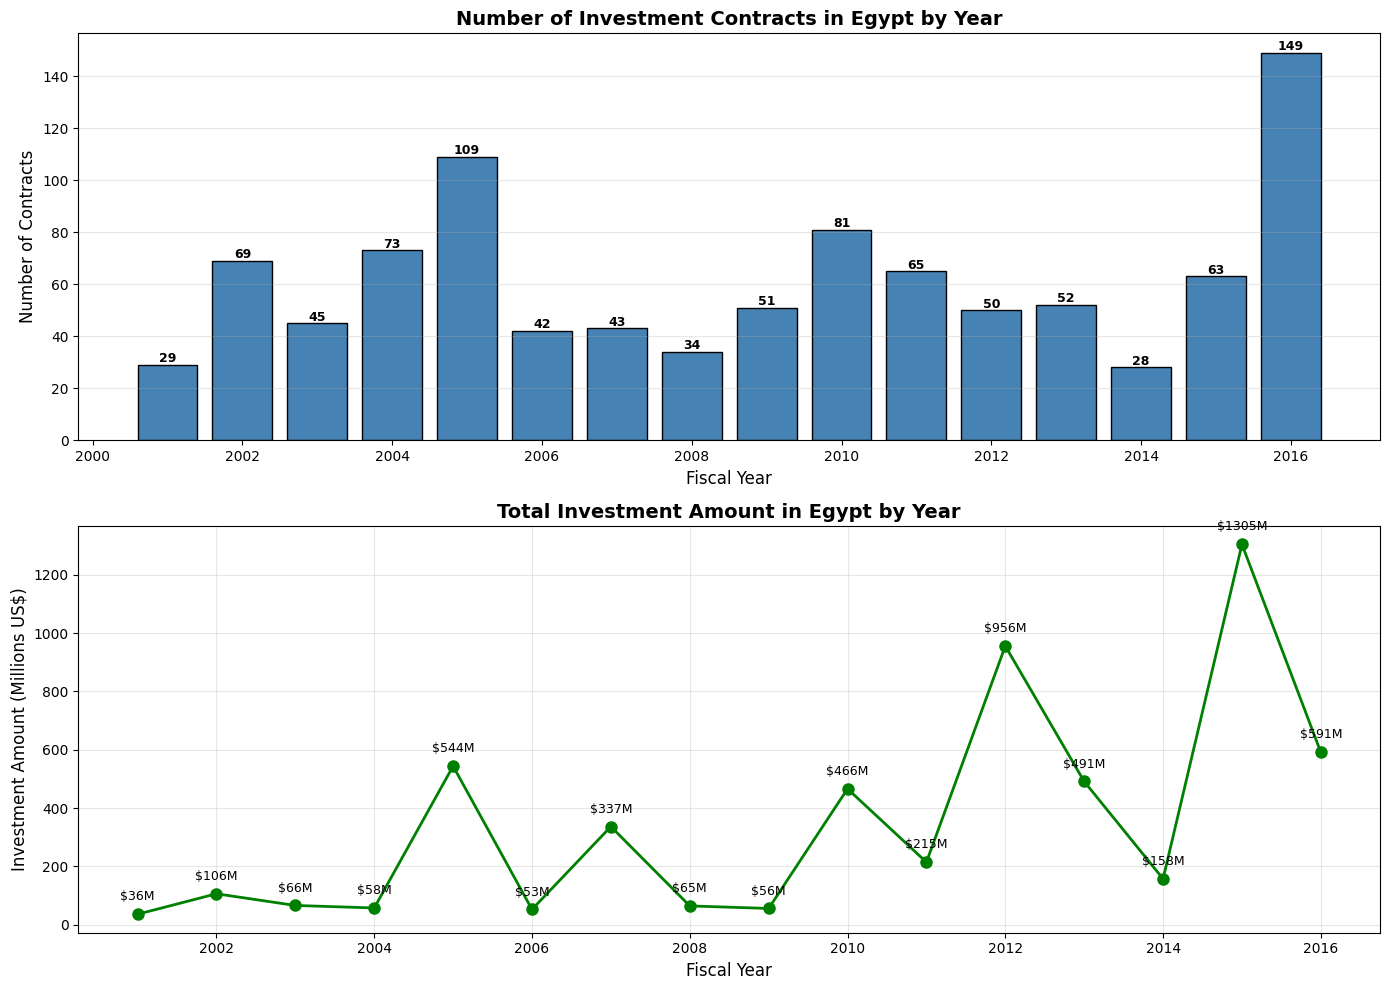

In [18]:
# Prepare data
yearly_contracts = df_egypt.groupby('Fiscal Year').size()
yearly_amount = df_egypt.groupby('Fiscal Year')['Supplier Contract Amount (US$)'].sum() / 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Number of contracts per year
axes[0].bar(yearly_contracts.index, yearly_contracts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Number of Investment Contracts in Egypt by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fiscal Year', fontsize=12)
axes[0].set_ylabel('Number of Contracts', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, (year, count) in enumerate(yearly_contracts.items()):
    axes[0].text(year, count + 1, str(count), ha='center', fontsize=9, fontweight='bold')

# Plot 2: Total investment amount per year
axes[1].plot(yearly_amount.index, yearly_amount.values, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_title('Total Investment Amount in Egypt by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fiscal Year', fontsize=12)
axes[1].set_ylabel('Investment Amount (Millions US$)', fontsize=12)
axes[1].grid(True, alpha=0.3)

for i, (year, amount) in enumerate(yearly_amount.items()):
    axes[1].annotate(f"${amount:.0f}M", (year, amount),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Cell 8: Feature Engineering 1 - Investment Category

In [19]:
# Categorize investment size
def investment_category(amount):
    if amount < 500000:
        return 'Small (<$500K)'
    elif amount < 2000000:
        return 'Medium ($500K-$2M)'
    elif amount < 10000000:
        return 'Large ($2M-$10M)'
    else:
        return 'Very Large (>$10M)'

df_egypt['Investment_Category'] = df_egypt['Supplier Contract Amount (US$)'].apply(investment_category)

print("Investment Category Distribution:")
print(df_egypt['Investment_Category'].value_counts())

Investment Category Distribution:
Investment_Category
Small (<$500K)        397
Medium ($500K-$2M)    352
Large ($2M-$10M)      174
Very Large (>$10M)     60
Name: count, dtype: int64


/tmp/ipykernel_1509/466936476.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_egypt['Investment_Category'] = df_egypt['Supplier Contract Amount (US$)'].apply(investment_category)


Cell 9: Outputs for Integration

In [20]:
print("="*60)
print("🎯 CONTRACTS - Final Output for Integration")
print("="*60)

max_year = yearly_contracts.idxmax()
max_count = yearly_contracts.max()
top_years = yearly_contracts.nlargest(3)

print(f"""
┌────────────────────────────────────────────────────────────────────────┐
│                    CONTRACTS FINGERPRINT                               │
├────────────────────────────────────────────────────────────────────────┤
│ 1. Total Contracts:                 {len(df_egypt):,}                  │
│ 2. Total Investment:                ${total_investment:,.2f}           │
│ 3. Peak Investment Year:            {max_year} ({max_count} contracts) │
│ 4. Top 3 Investment Years:          {list(top_years.index)}            │
│ 5. Average Contract Value:          ${amounts.mean():,.2f}             │
└────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ CONTRACTS FILE ANALYSIS COMPLETE")

🎯 CONTRACTS - Final Output for Integration

┌────────────────────────────────────────────────────────────────────────┐
│                    CONTRACTS FINGERPRINT                               │
├────────────────────────────────────────────────────────────────────────┤
│ 1. Total Contracts:                 983                  │
│ 2. Total Investment:                $5,502,962,216.00           │
│ 3. Peak Investment Year:            2016 (149 contracts) │
│ 4. Top 3 Investment Years:          [2016, 2005, 2010]            │
│ 5. Average Contract Value:          $5,598,130.43             │
└────────────────────────────────────────────────────────────────────────┘


✅ CONTRACTS FILE ANALYSIS COMPLETE
